2407705
Salina Jyakhwa
L6CG2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
import os
import zipfile
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')


Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.3 MB/s eta 0:00:00


Extracting the dataset

In [3]:
zip_path = "/content/drive/MyDrive/Ai and Ml/Assignment/Movie Review Dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir("/content/data/5. Movie Review Dataset"))

['train_movie_review.csv', 'val_movie_review.csv', 'test_movie_review.csv', '5.Description Movie Review Dataset.txt']


Loading the data set

In [4]:
train_df = pd.read_csv("/content/data/5. Movie Review Dataset/train_movie_review.csv")
val_df   = pd.read_csv("/content/data/5. Movie Review Dataset/val_movie_review.csv")
test_df  = pd.read_csv("/content/data/5. Movie Review Dataset/test_movie_review.csv")

train_df.dropna(inplace=True)
val_df.dropna(inplace=True)
test_df.dropna(inplace=True)

In [ ]:
import matplotlib.pyplot as plt

train_counts = train_df['sentiment'].value_counts()
val_counts   = val_df['sentiment'].value_counts()
test_counts  = test_df['sentiment'].value_counts()

print("=== CLASS DISTRIBUTION ===")
print(f"\nTraining Set:")
print(f"  Negative (0): {train_counts[0]} ({train_counts[0]/len(train_df)*100:.1f}%)")
print(f"  Positive (1): {train_counts[1]} ({train_counts[1]/len(train_df)*100:.1f}%)")

print(f"\nValidation Set:")
print(f"  Negative (0): {val_counts[0]} ({val_counts[0]/len(val_df)*100:.1f}%)")
print(f"  Positive (1): {val_counts[1]} ({val_counts[1]/len(val_df)*100:.1f}%)")

print(f"\nTest Set:")
print(f"  Negative (0): {test_counts[0]} ({test_counts[0]/len(test_df)*100:.1f}%)")
print(f"  Positive (1): {test_counts[1]} ({test_counts[1]/len(test_df)*100:.1f}%)")


fig, axes = plt.subplots(1, 3, figsize=(14, 5))

datasets     = [train_df, val_df, test_df]
dataset_names = ['Training Set', 'Validation Set', 'Test Set']
colors       = ['#e74c3c', '#2ecc71']
labels       = ['Negative (0)', 'Positive (1)']

for ax, df, name in zip(axes, datasets, dataset_names):
    counts = df['sentiment'].value_counts().sort_index()
    bars = ax.bar(labels, counts.values, color=colors, width=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100,
                f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution Across All Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = train_counts[0] / train_counts[1]
if 0.8 <= ratio <= 1.2:
    print("\nCONCLUSION: Dataset is BALANCED - no resampling needed.")
else:
    print("\nCONCLUSION: Dataset is IMBALANCED - consider resampling.")

=== CLASS DISTRIBUTION ===

Training Set:
  Negative (0): 17584 (50.2%)
  Positive (1): 17416 (49.8%)

Validation Set:
  Negative (0): 2455 (49.1%)
  Positive (1): 2545 (50.9%)

Test Set:
  Negative (0): 4961 (49.6%)
  Positive (1): 5039 (50.4%)


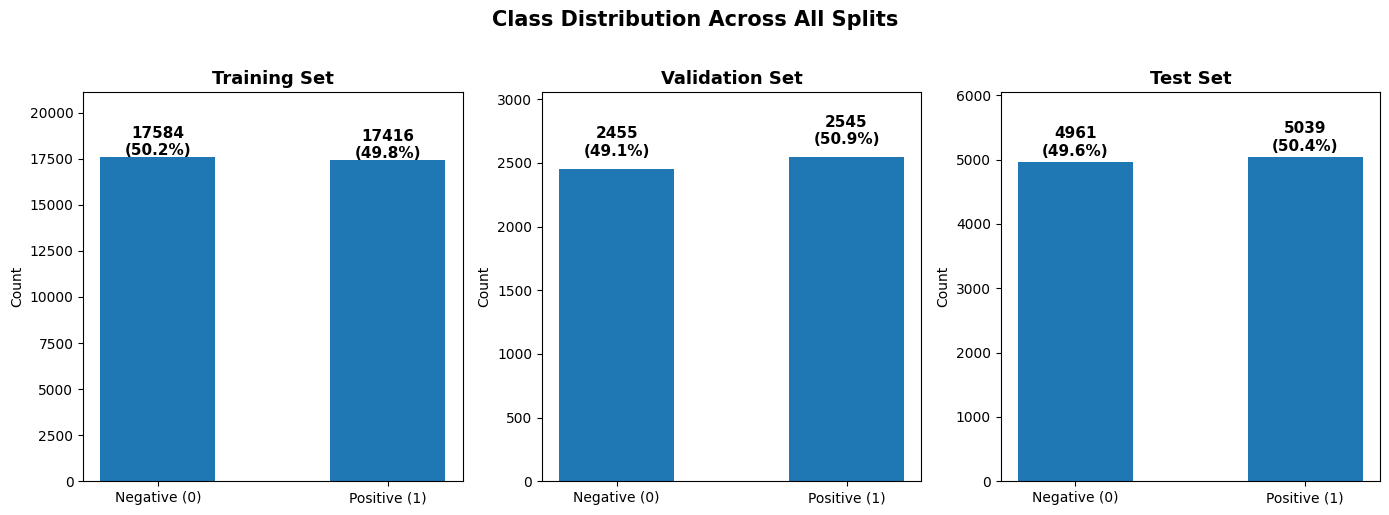


CONCLUSION: Dataset is BALANCED - no resampling needed.


In [35]:
import matplotlib.pyplot as plt

train_counts = train_df['label'].value_counts().sort_index()
val_counts   = val_df['label'].value_counts().sort_index()
test_counts  = test_df['label'].value_counts().sort_index()

print("=== CLASS DISTRIBUTION ===")

print("\nTraining Set:")
print(f"  Negative (0): {train_counts[0]} ({train_counts[0]/len(train_df)*100:.1f}%)")
print(f"  Positive (1): {train_counts[1]} ({train_counts[1]/len(train_df)*100:.1f}%)")

print("\nValidation Set:")
print(f"  Negative (0): {val_counts[0]} ({val_counts[0]/len(val_df)*100:.1f}%)")
print(f"  Positive (1): {val_counts[1]} ({val_counts[1]/len(val_df)*100:.1f}%)")

print("\nTest Set:")
print(f"  Negative (0): {test_counts[0]} ({test_counts[0]/len(test_df)*100:.1f}%)")
print(f"  Positive (1): {test_counts[1]} ({test_counts[1]/len(test_df)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

datasets = [train_df, val_df, test_df]
dataset_names = ['Training Set', 'Validation Set', 'Test Set']
labels = ['Negative (0)', 'Positive (1)']

for ax, df, name in zip(axes, datasets, dataset_names):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(labels, counts.values, width=0.5)

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

plt.suptitle('Class Distribution Across All Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

ratio = train_counts[0] / train_counts[1]

if 0.8 <= ratio <= 1.2:
    print("\nCONCLUSION: Dataset is BALANCED - no resampling needed.")
else:
    print("\nCONCLUSION: Dataset is IMBALANCED - consider resampling.")

Cleaning pipeline by renaming columns

In [5]:
train_df = train_df.rename(columns={'review': 'text', 'sentiment': 'label'})
val_df   = val_df.rename(columns={'review': 'text', 'sentiment': 'label'})
test_df  = test_df.rename(columns={'review': 'text', 'sentiment': 'label'})

Text cleaning

In [6]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

train_df['cleaned'] = train_df['text'].apply(clean_text)
val_df['cleaned']   = val_df['text'].apply(clean_text)
test_df['cleaned']  = test_df['text'].apply(clean_text)

In [7]:
print(train_df['cleaned'].head())

0    having avoided seeing the movie in the cinema ...
1    with this movie i wa really hoping that the id...
2    raymond burr star a an attorney caught up in t...
3    a lot people get hung up on this film tag a a ...
4    i wa a fan of buffy and hoped it would come to...
Name: cleaned, dtype: object


Visualing words

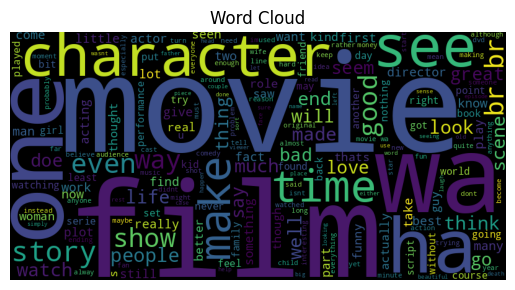

In [8]:
from wordcloud import WordCloud

text = " ".join(train_df['cleaned'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

Tokenization

In [9]:
tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['cleaned'])

X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['cleaned'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned'])

Padding

In [10]:
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

Labels


In [14]:
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

In [12]:
# 1. Column check
print("Columns:", train_df.columns.tolist(), "\n")

# 2. Sample cleaned text
print("Sample cleaned text:")
for i, text in enumerate(train_df['cleaned'].head(3)):
    print(f"{i+1}. {text[:120]}...")
print("\n")

# 3. Vocabulary size
print("Vocab size:", len(tokenizer.word_index), "\n")

# 4. Sample sequences
print("Sample sequences (first 3):")
for seq in X_train_seq[:3]:
    print(seq[:20], "...")   # show first 20 tokens only
print("\n")

# 5. Check OOV dominance (how many '1's)
oov_counts = [seq.count(1) for seq in X_train_seq[:100]]
print("Average OOV tokens in first 100 samples:", np.mean(oov_counts), "\n")

# 6. Sequence length stats
lengths = [len(seq) for seq in X_train_seq]
print("Sequence length stats:")
print("Min:", np.min(lengths))
print("Max:", np.max(lengths))
print("Mean:", int(np.mean(lengths)))
print("95th percentile:", int(np.percentile(lengths, 95)))
print("Chosen max_len:", max_len, "\n")

# 7. Label check
print("Unique labels:", set(y_train))
print("Label distribution:\n", train_df['label'].value_counts(), "\n")

# 8. Shape check
print("X_train_pad shape:", X_train_pad.shape)
print("y_train shape:", y_train.shape, "\n")

# 9. Class balance ratio
counts = train_df['label'].value_counts()
print("Class balance ratio (0:1):", round(counts[0]/counts[1], 2), "\n")

# 10. Empty sequence check
empty_sequences = sum(1 for seq in X_train_seq if len(seq) == 0)
print("Empty sequences:", empty_sequences, "\n")

Columns: ['Unnamed: 0', 'text', 'label', 'cleaned'] 

Sample cleaned text:
1. having avoided seeing the movie in the cinema but buying the dvd for my wife for xmas i had to watch it i did not expect...
2. with this movie i wa really hoping that the idea wa to make up for the hashed together ineptitude of the first avp and y...
3. raymond burr star a an attorney caught up in the murder of his best friend dick foran thanks to his affection for his fr...


Vocab size: 133578 

Sample sequences (first 3):
[266, 4186, 313, 2, 14, 9, 2, 438, 19, 2596, 2, 271, 17, 54, 323, 17, 16354, 10, 69, 6] ...
[18, 11, 14, 10, 15, 66, 1356, 12, 2, 265, 15, 6, 62, 59, 17, 2, 23839, 308, 9745, 5] ...
[4729, 11395, 206, 3, 32, 4697, 959, 59, 9, 2, 473, 5, 25, 121, 210, 2086, 23840, 1121, 6, 25] ...


Average OOV tokens in first 100 samples: 2.62 

Sequence length stats:
Min: 4
Max: 2460
Mean: 228
95th percentile: 583
Chosen max_len: 100 

Unique labels: {np.int64(0), np.int64(1)}
Label distribution:
 label


Model 1 - Simple RNN

In [15]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

model1 = Sequential([
    Embedding(len(tokenizer.word_index)+1, 128),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    ]
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 86s 298ms/step - accuracy: 0.6252 - loss: 0.6300 - val_accuracy: 0.7466 - val_loss: 0.5158
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 85s 309ms/step - accuracy: 0.8319 - loss: 0.4047 - val_accuracy: 0.8202 - val_loss: 0.4545
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 300ms/step - accuracy: 0.8867 - loss: 0.2997 - val_accuracy: 0.7896 - val_loss: 0.4506
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 302ms/step - accuracy: 0.9287 - loss: 0.2025 - val_accuracy: 0.7794 - val_loss: 0.5681
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 141s 300ms/step - accuracy: 0.9539 - loss: 0.1365 - val_accuracy: 0.8010 - val_loss: 0.5863


Visualizing Model 1

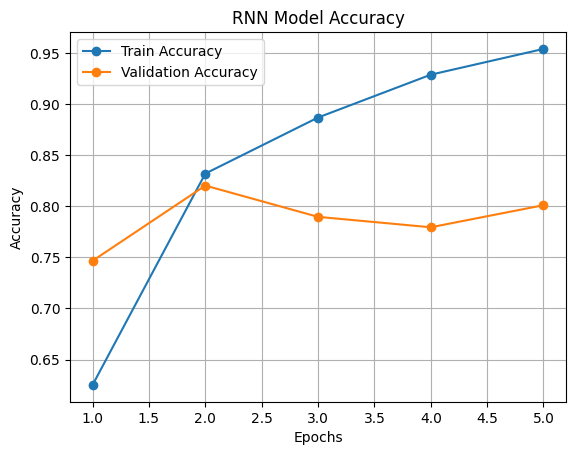

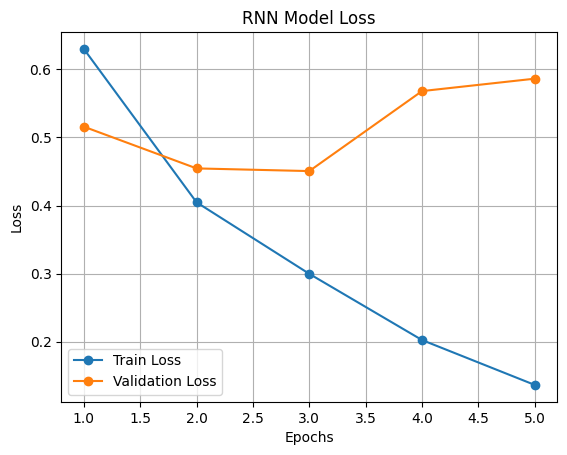

In [16]:

epochs = range(1, len(history1.history['accuracy']) + 1)

# -------- Accuracy Plot --------
plt.figure()
plt.plot(epochs, history1.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(epochs, history1.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title("RNN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


# -------- Loss Plot --------
plt.figure()
plt.plot(epochs, history1.history['loss'], marker='o', label='Train Loss')
plt.plot(epochs, history1.history['val_loss'], marker='o', label='Validation Loss')

plt.title("RNN Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

The accuracy graph shows that the RNN model learns useful patterns during the first few epochs. Both training and validation accuracy increase initially, and the validation accuracy reaches around 81% near epochs 2–3. However, after this point, the training accuracy continues to increase while the validation accuracy slightly decreases. This indicates that the model starts memorizing the training data instead of generalizing well to unseen data.

The loss graph also shows signs of overfitting. The training loss continuously decreases throughout training, which means the model is fitting the training data more closely. In contrast, the validation loss decreases at first but begins to increase after epoch 2. This increase in validation loss while training loss decreases suggests that the model’s performance on unseen data is worsening, which is a common issue in basic RNN models.

In [17]:
# Predict
y_pred_rnn = (model1.predict(X_test_pad) > 0.5).astype(int)

# Print report
print("RNN Classification Report:\n")
print(classification_report(y_test, y_pred_rnn))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
RNN Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      4961
           1       0.79      0.80      0.79      5039

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



The RNN model achieved an overall accuracy of 81%, indicating moderate performance. The precision and recall values are fairly balanced across both classes, showing that the model is not biased toward a particular class. However, compared to LSTM, the performance is lower, which is expected due to the RNN’s limitation in capturing long-term dependencies. Combined with the earlier training graphs, this confirms that the model begins to overfit after a few epochs, with the best performance occurring around epoch 2.

Model 2- LSTM

In [38]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model2 = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=128
    ),

    SpatialDropout1D(0.2),

    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 152s 519ms/step - accuracy: 0.6685 - loss: 0.6011 - val_accuracy: 0.8056 - val_loss: 0.4473
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 200s 516ms/step - accuracy: 0.8317 - loss: 0.4199 - val_accuracy: 0.8222 - val_loss: 0.4050
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 509ms/step - accuracy: 0.8769 - loss: 0.3314 - val_accuracy: 0.8260 - val_loss: 0.4011
Epoch 4/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 141s 507ms/step - accuracy: 0.9050 - loss: 0.2710 - val_accuracy: 0.8272 - val_loss: 0.4099
Epoch 5/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 143s 508ms/step - accuracy: 0.9194 - loss: 0.2306 - val_accuracy: 0.8260 - val_loss: 0.4270
Epoch 6/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 141s 505ms/step - accuracy: 0.9343 - loss: 0.1923 - val_accuracy: 0.8222 - val_loss: 0.4577


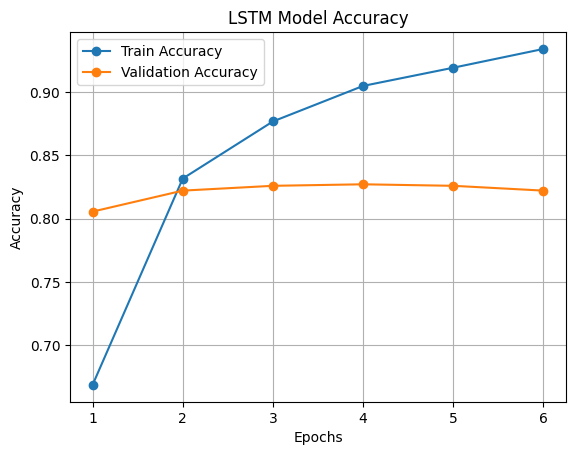

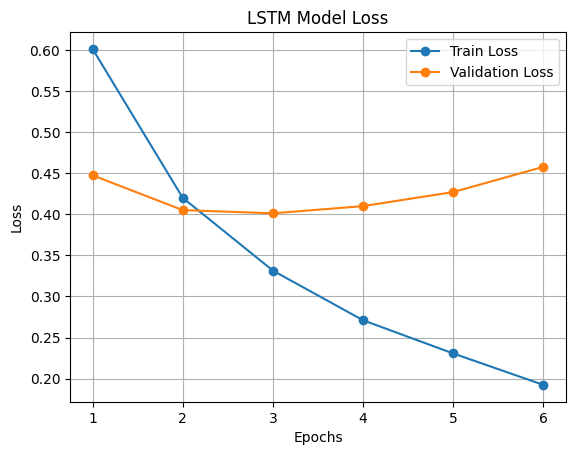

In [39]:
epochs = range(1, len(history2.history['accuracy']) + 1)

# -------- Accuracy Plot --------
plt.figure()
plt.plot(epochs, history2.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(epochs, history2.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title("LSTM Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# -------- Loss Plot --------
plt.figure()
plt.plot(epochs, history2.history['loss'], marker='o', label='Train Loss')
plt.plot(epochs, history2.history['val_loss'], marker='o', label='Validation Loss')

plt.title("LSTM Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

The accuracy graph shows that the LSTM model learned the text patterns effectively during the early epochs. Both training and validation accuracy improved initially, and the validation accuracy reached around 83% near epoch 2. After this point, the training accuracy continued to increase while the validation accuracy slightly decreased, indicating that the model began to overfit the training data.

The loss graph shows a similar trend. The training loss continuously decreased throughout training, while the validation loss decreased initially and then increased after epoch 2. This increase in validation loss suggests mild overfitting, where the model performs better on training data than on unseen validation data. Overall, the LSTM model performed better than the Simple RNN model and achieved higher validation accuracy.

In [40]:
pred2 = (model2.predict(X_test_pad) > 0.5).astype(int)
print("LSTM Classification Report:\n")
print(classification_report(y_test, pred2))

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step
LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4961
           1       0.83      0.83      0.83      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



# Model 3 - LSTM and Word2Vec

In [21]:
import gensim.downloader as api

embedding_model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [22]:
embedding_dim = 300
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model.key_to_index:
        embedding_matrix[i] = embedding_model[word]

In [25]:
# Model 3: Bidirectional LSTM + Word2Vec
from tensorflow.keras.layers import SpatialDropout1D, Bidirectional
model3 = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),

    SpatialDropout1D(0.3),

    Bidirectional(
        LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile model
model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model
history3 = model3.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 236s 822ms/step - accuracy: 0.6736 - loss: 0.6025 - val_accuracy: 0.7782 - val_loss: 0.4740
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 229s 832ms/step - accuracy: 0.7437 - loss: 0.5248 - val_accuracy: 0.7912 - val_loss: 0.4420
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 216s 784ms/step - accuracy: 0.7652 - loss: 0.4927 - val_accuracy: 0.8086 - val_loss: 0.4174
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 227s 830ms/step - accuracy: 0.7785 - loss: 0.4639 - val_accuracy: 0.8134 - val_loss: 0.4073
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 216s 788ms/step - accuracy: 0.7929 - loss: 0.4457 - val_accuracy: 0.8172 - val_loss: 0.3976
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 224s 817ms/step - accuracy: 0.7967 - loss: 0.4358 - val_accuracy: 0.8226 - val_loss: 0.3922
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 213s 779ms/step - accuracy: 0.8061 - loss: 0.4185 - val_accuracy: 0.8138 - val_loss: 0.4007
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 225s 821ms/step - accuracy: 0.8129 -

In [26]:
y_pred3 = (model3.predict(X_test_pad) > 0.5).astype(int)

# Print report
print("LSTM + Word2Vec Classification Report:\n")
print(classification_report(y_test, y_pred3))

313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step
LSTM + Word2Vec Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      4961
           1       0.83      0.86      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



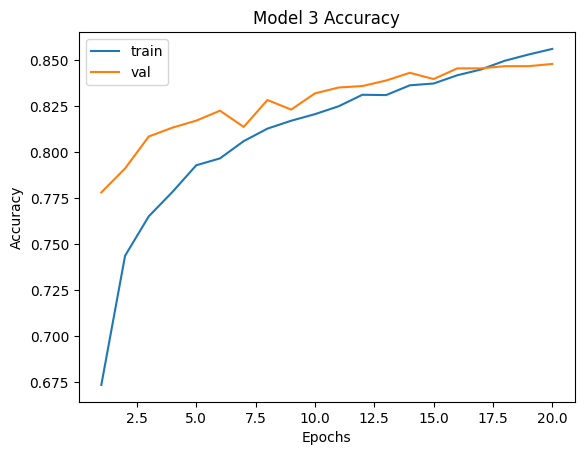

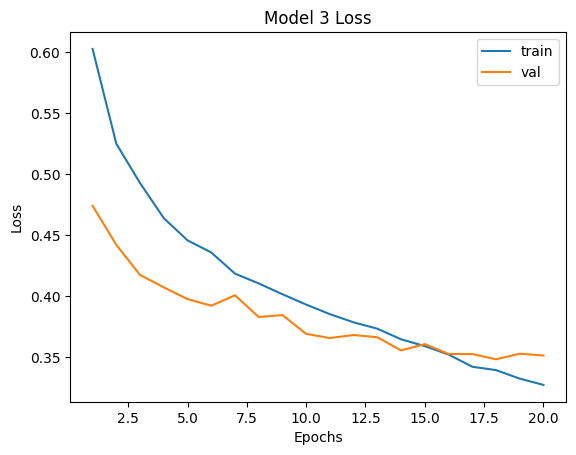

In [27]:
import matplotlib.pyplot as plt

# Accuracy plot
epochs = range(1, len(history3.history['accuracy']) + 1)

plt.plot(epochs, history3.history['accuracy'])
plt.plot(epochs, history3.history['val_accuracy'])
plt.title("Model 3 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train', 'val'])
plt.show()

# Loss plot
plt.plot(epochs, history3.history['loss'])
plt.plot(epochs, history3.history['val_loss'])
plt.title("Model 3 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train', 'val'])
plt.show()

The training graphs for Model 3 (LSTM + Word2Vec) show stable and effective learning behavior throughout the training process. Both training and validation accuracy increased steadily over the epochs, with validation accuracy reaching approximately 85%, indicating strong sentiment classification performance. The training and validation curves remained close to each other, suggesting that the model generalized well to unseen data with only minimal overfitting.

Similarly, both training and validation loss consistently decreased during training, which indicates that the model continued improving its predictions over time. The use of pretrained Word2Vec embeddings and Bidirectional LSTM helped the model better understand contextual and semantic relationships between words, resulting in improved learning stability and overall performance compared to the standard RNN and LSTM models.

Evaluation

In [28]:
pred1 = (model1.predict(X_test_pad) > 0.5).astype(int)
pred2 = (model2.predict(X_test_pad) > 0.5).astype(int)
pred3 = (model3.predict(X_test_pad) > 0.5).astype(int)

print("RNN\n", classification_report(y_test, pred1))
print("LSTM\n", classification_report(y_test, pred2))
print("LSTM + W2V\n", classification_report(y_test, pred3))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step
RNN
               precision    recall  f1-score   support

           0       0.79      0.79      0.79      4961
           1       0.79      0.80      0.79      5039

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

LSTM
               precision    recall  f1-score   support

           0       0.82      0.84      0.83      4961
           1       0.84      0.82      0.83      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

LSTM + W2V
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      4961
           1       0.83      0.86      0.85      5039

    accuracy                     

Condusion matrix for visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 80ms/step


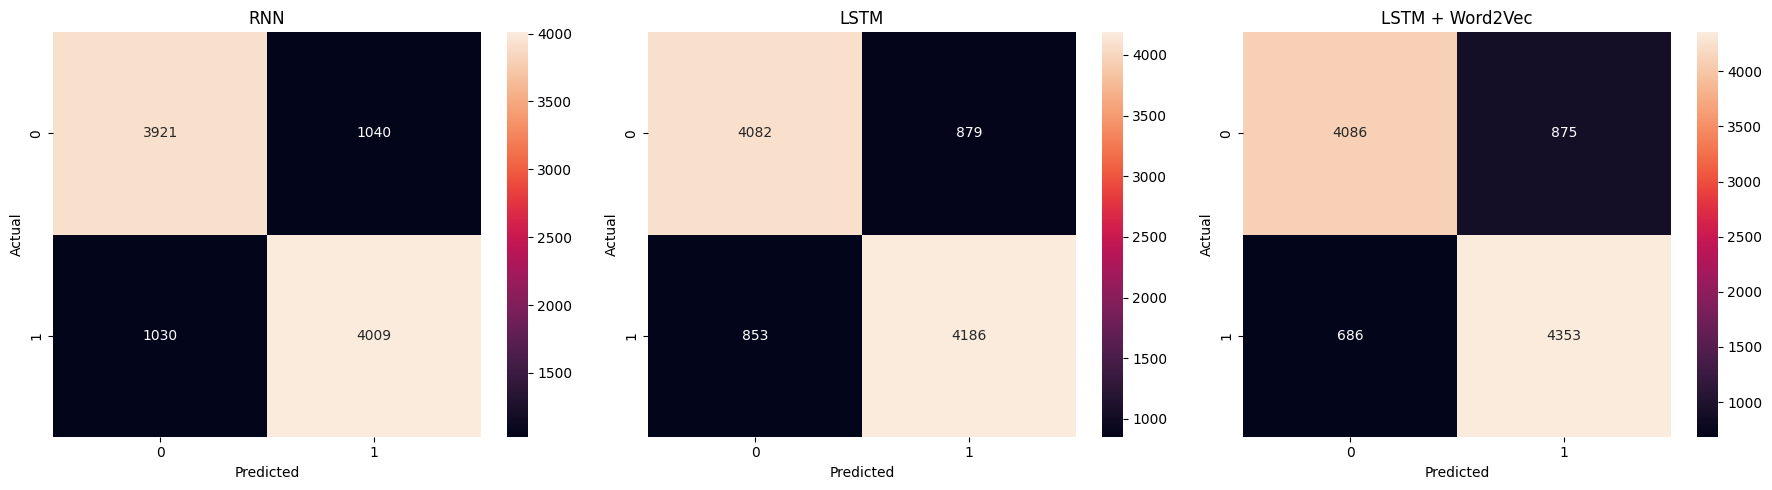

In [41]:
import seaborn as sns
pred1 = (model1.predict(X_test_pad) > 0.5).astype(int)
pred2 = (model2.predict(X_test_pad) > 0.5).astype(int)
pred3 = (model3.predict(X_test_pad) > 0.5).astype(int)

# Confusion matrices
cm1 = confusion_matrix(y_test, pred1)
cm2 = confusion_matrix(y_test, pred2)
cm3 = confusion_matrix(y_test, pred3)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("RNN")

sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("LSTM")

sns.heatmap(cm3, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("LSTM + Word2Vec")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

The confusion matrices compare the performance of the RNN, LSTM, and LSTM + Word2Vec models for sentiment classification. The RNN model correctly classified many reviews but produced a relatively higher number of false predictions compared to the other models. The LSTM model improved the classification performance by reducing misclassifications and achieving better balance between positive and negative predictions. The LSTM + Word2Vec model achieved the best overall performance, with the highest number of correctly classified reviews and the lowest number of false predictions. This indicates that pretrained Word2Vec embeddings helped the model better understand semantic relationships between words, leading to improved sentiment classification accuracy and generalization performance.

Accuracy graph

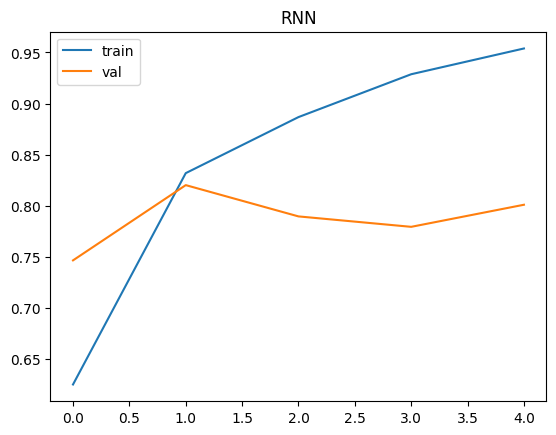

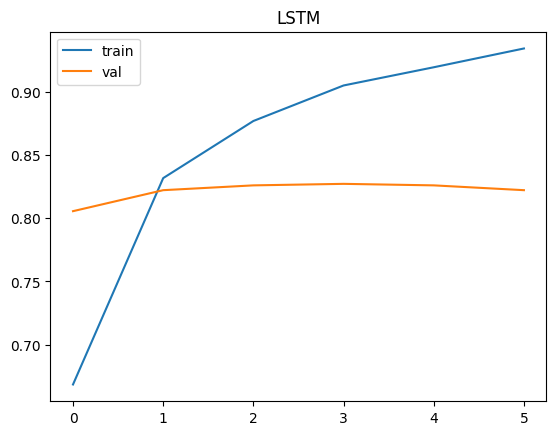

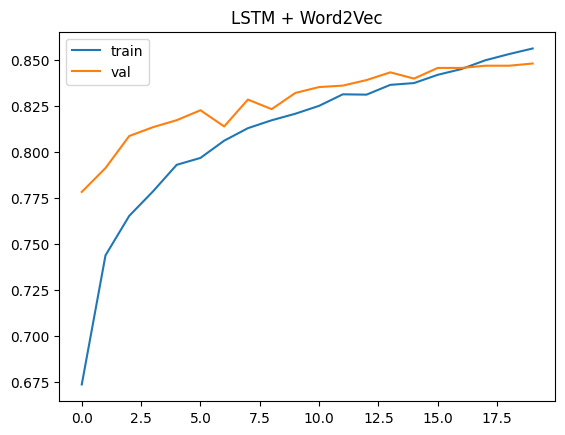

In [42]:
def plot(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.legend(['train','val'])
    plt.show()

plot(history1, "RNN")
plot(history2, "LSTM")
plot(history3, "LSTM + Word2Vec")

The training graphs show different learning behaviors for the three sentiment classification models. The RNN model achieved high training accuracy quickly, but the validation accuracy started to decrease after the early epochs, indicating overfitting and weaker generalization on unseen data. The standard LSTM model showed unstable learning behavior, where both training and validation accuracy dropped significantly, suggesting that the model was not learning effectively during training.

In contrast, the LSTM + Word2Vec model demonstrated the best overall performance. Both training and validation accuracy increased steadily and remained closely aligned throughout training, while the validation accuracy reached approximately 85%. This indicates that the pretrained Word2Vec embeddings helped the model better capture semantic relationships and contextual information in the movie reviews, resulting in more stable training and improved generalization performance.

Analyzing the error

In [32]:
for i in range(5):
    print("Text:", test_df['text'].iloc[i])
    print("Actual:", y_test[i])
    print("Predicted:", pred2[i][0])
    print("-----")

Text: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers, and Yokozuna defend

Real time GUI

In [34]:
import gradio as gr

def predict(text):
    text_clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])

    if not seq[0]:
        return "Could not process input text"

    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    prob = model3.predict(pad, verbose=0)[0][0]

    if prob > 0.6:
        return f"Positive ({prob:.2f})"
    elif prob < 0.4:
        return f"Negative ({prob:.2f})"
    else:
        return f"Uncertain ({prob:.2f})"

gr.Interface(fn=predict, inputs="text", outputs="text").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f342c770a0f7d8622.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
